In [78]:
import pandas as pd 
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

In [79]:
df = pd.read_csv("../data/drug_discovery_virtual_screening.csv")
df

,compound_id,protein_id,molecular_weight,logp,h_bond_donors,h_bond_acceptors,rotatable_bonds,polar_surface_area,compound_clogp,protein_length,protein_pi,hydrophobicity,binding_site_size,mw_ratio,logp_pi_interaction,binding_affinity,active
0,CID_00000,PID_361,499.671415,2.487233,1,7,4,113.350817,4.050696,678,6.019657,0.812534,12.512165,0.736978,14.972288,5.996665,0
1,CID_00001,PID_165,436.173570,3.283222,3,4,4,71.981132,3.704408,876,6.447408,0.651417,11.538420,0.497915,21.168271,6.445742,0
2,CID_00002,PID_168,514.768854,NaN,2,11,11,83.936307,1.869610,658,3.925837,0.633467,13.155702,0.782323,9.074061,5.689583,0
3,CID_00003,PID_226,602.302986,3.038058,0,5,5,79.868125,2.451909,312,7.597056,0.513038,12.071822,1.930458,23.080293,6.043438,0
4,CID_00004,PID_224,426.584663,0.659578,2,4,5,88.198676,1.771936,1418,4.249454,0.613571,15.850448,0.300835,2.802846,4.845055,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,CID_01995,PID_425,557.015024,3.542686,4,5,11,102.329688,1.470121,240,7.862185,0.770925,21.308909,2.320896,27.853256,7.209850,1
1996,CID_01996,PID_100,447.347874,0.383282,1,8,5,52.321214,3.739447,718,7.401501,0.644721,16.578658,0.623047,2.836864,9.029696,1
1997,CID_01997,PID_265,361.812535,3.019553,0,4,9,86.722469,3.122027,1228,5.551238,0.717044,16.829751,0.294636,16.762259,5.728118,0
1998,CID_01998,PID_125,433.693304,5.965067,0,4,10,86.932238,3.866579,1244,5.680128,0.661245,10.604194,0.348628,33.882348,7.324152,1


In [80]:

df_test_rot_12 = df[df['rotatable_bonds'] >= 12]
df_test_pid_170 = df[df['protein_id'] == "PID_170"]

df_train = df[df['protein_id'] != "PID_170"]
df_train = df_train[df_train['binding_site_size'] < 12]

df_train = df_train.dropna()
df_test_rot_12 = df_test_rot_12.dropna()
df_test_pid_170 = df_test_pid_170.dropna()


In [81]:
X_train = df_train.drop(columns=["active", "compound_id", "protein_id", "binding_affinity"])
y_train = df_train["active"]

X_train

,molecular_weight,logp,h_bond_donors,h_bond_acceptors,rotatable_bonds,polar_surface_area,compound_clogp,protein_length,protein_pi,hydrophobicity,binding_site_size,mw_ratio,logp_pi_interaction
1,436.173570,3.283222,3,4,4,71.981132,3.704408,876,6.447408,0.651417,11.538420,0.497915,21.168271
20,596.564877,3.589899,4,2,4,51.873309,4.223444,1345,6.020609,0.773173,11.706540,0.443543,21.613377
46,403.936123,3.500311,2,7,11,53.369458,3.717434,410,6.973966,0.576425,8.972350,0.985210,24.411046
60,402.082576,4.776347,3,9,4,52.304281,2.391988,507,9.245964,0.701877,7.120231,0.793062,44.161930
64,531.252582,3.898044,0,3,4,60.395202,3.802747,1346,5.620260,0.546615,7.939757,0.394690,21.908017
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1963,514.521559,4.653260,2,2,3,60.347893,2.210368,1349,8.044696,0.663360,10.776180,0.381410,37.434057
1967,434.872672,0.665526,1,5,10,57.278663,3.619721,332,9.402383,0.703034,11.782443,1.309857,6.257531
1975,411.148155,3.787366,2,2,7,69.455592,4.841849,850,9.899048,0.511988,11.938972,0.483704,37.491317
1980,352.834327,5.543844,2,7,10,64.234334,3.366897,1214,7.258519,0.454989,9.623733,0.290638,40.240098


In [82]:
X_test_pid_170 = df_test_pid_170.drop(columns=["active", "compound_id", "protein_id", "binding_affinity"])
y_test_pid_170 = df_test_pid_170["active"]

X_test_pid_170

,molecular_weight,logp,h_bond_donors,h_bond_acceptors,rotatable_bonds,polar_surface_area,compound_clogp,protein_length,protein_pi,hydrophobicity,binding_site_size,mw_ratio,logp_pi_interaction
83,398.172978,0.055729,2,9,6,75.610244,1.507370,315,5.687165,0.616042,17.669424,1.264041,0.316938
232,454.557184,0.544844,4,10,7,98.052847,4.528891,852,4.511350,0.671554,20.253551,0.533518,2.457983
251,541.786195,5.766732,1,7,8,83.081307,-0.939139,1197,8.081775,0.564998,11.874890,0.452620,46.605432
335,435.294262,4.362808,0,6,7,83.443277,2.212231,754,7.295129,0.423372,14.680066,0.577313,31.827242
493,363.871580,5.665448,3,6,5,79.910970,2.038442,1336,8.329196,0.723462,15.322348,0.272359,47.188629
762,706.008454,4.843033,3,2,5,107.914059,3.681169,1431,7.069725,0.728868,8.760632,0.493367,34.238914
1044,432.737270,4.571915,3,6,7,94.026534,1.963259,920,7.616123,0.758956,16.421568,0.470367,34.820263
1306,452.818116,4.298009,0,3,7,114.631565,2.607672,297,6.582112,0.711852,13.303714,1.524640,28.289977
1679,406.837969,3.374423,1,4,14,122.130603,5.105506,1291,4.868744,0.606039,17.993339,0.315134,16.429202


In [83]:
X_test_rot_12 = df_test_rot_12.drop(columns=["active", "compound_id", "protein_id", "binding_affinity"])
y_test_rot_12 = df_test_rot_12["active"]

X_test_rot_12

,molecular_weight,logp,h_bond_donors,h_bond_acceptors,rotatable_bonds,polar_surface_area,compound_clogp,protein_length,protein_pi,hydrophobicity,binding_site_size,mw_ratio,logp_pi_interaction
39,469.686124,0.846386,6,4,14,107.774094,2.213341,1132,8.497576,0.513184,14.103294,0.414917,7.192230
163,367.931768,5.210224,1,5,14,141.737510,4.298416,832,5.731849,0.540239,11.225122,0.442226,29.864216
222,518.626019,4.616288,0,6,14,137.631109,0.516374,1340,6.139622,0.707208,15.684260,0.387034,28.342261
265,325.221682,5.288761,3,2,14,109.483441,1.445682,597,5.234197,0.688759,13.254669,0.544760,27.682420
275,496.210347,1.871262,3,7,12,91.329153,3.311306,280,6.227987,0.570778,15.920940,1.772180,11.654198
278,456.980208,4.499469,1,3,13,80.412850,4.490907,482,5.755926,0.575758,15.645421,0.948092,25.898610
284,663.303337,2.803394,4,8,13,101.776031,2.752464,1454,8.281876,0.718955,16.187957,0.456192,23.217359
310,428.231880,3.018999,2,5,12,84.844909,2.917327,1197,7.177466,0.476238,13.647018,0.357754,21.668760
406,343.237957,1.550628,4,6,14,80.940639,1.634838,629,5.465823,0.632332,14.777264,0.545688,8.475459
529,359.568337,1.803667,2,4,12,13.243061,3.130597,688,5.414596,0.571965,15.570961,0.522628,9.766129


In [84]:
stnd = StandardScaler().set_output(transform='pandas')
X_train = stnd.fit_transform(X_train)
X_test_rot_12 = stnd.transform(X_test_rot_12)
X_test_pid_170 = stnd.transform(X_test_pid_170)

In [85]:
l2 = LogisticRegression(penalty="l2", solver="liblinear", C=10, max_iter=10000)
l2.fit(X_train, y_train)

c:\Users\franklkj\Documents\CSSEMA415\src\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l2'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",10
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` 

In [86]:
y_pred_pid_170 = l2.predict(X_test_pid_170)

In [87]:
results_pid_170 = pd.concat([y_test_pid_170.reset_index(), pd.Series(y_pred_pid_170, name="predicted"), X_test_pid_170.reset_index(drop=True)], axis=1).set_index("index")

In [88]:
results_pid_170

,active,predicted,molecular_weight,logp,h_bond_donors,h_bond_acceptors,rotatable_bonds,polar_surface_area,compound_clogp,protein_length,protein_pi,hydrophobicity,binding_site_size,mw_ratio,logp_pi_interaction
index,,,,,,,,,,,,,,,
83,0,0,-0.522797,-2.145683,0.041359,1.617563,-0.037812,-0.160941,-1.189918,-1.389189,-0.639729,-0.288986,5.154903,1.218945,-2.122884
232,0,0,-0.015317,-1.850682,1.491666,2.037523,0.376546,0.719546,1.391574,-0.002837,-1.567336,0.271173,6.973176,-0.358954,-1.924453
251,1,1,0.769779,1.298805,-0.683795,0.777644,0.790903,0.132170,-3.280136,0.887836,1.249391,-0.804061,1.077687,-0.533690,2.167109
335,1,1,-0.188691,0.452053,-1.408949,0.357684,0.376546,0.146371,-0.587707,-0.255840,0.628802,-2.233172,3.051497,-0.264358,0.797475
493,1,1,-0.831523,1.237717,0.766512,0.357684,-0.452170,0.007788,-0.736187,1.246687,1.444583,0.794960,3.503427,-0.923046,2.221160
762,1,1,2.247844,0.741693,0.766512,-1.322154,-0.452170,1.106430,0.667307,1.491945,0.450980,0.849516,-1.113603,-0.445678,1.020987
1044,1,1,-0.211705,0.578173,0.766512,0.357684,0.376546,0.561582,-0.800421,0.172716,0.882036,1.153120,4.276872,-0.495358,1.074866
1306,0,1,-0.030969,0.412971,-1.408949,-0.902195,0.376546,1.369977,-0.249854,-1.435659,0.066299,0.677811,2.083052,1.781827,0.469643
1679,0,0,-0.444809,-0.144073,-0.683795,-0.482235,3.277050,1.664185,1.884214,1.130513,-1.285386,-0.389931,5.382820,-0.830654,-0.629608


In [89]:
y_pred_rot_12 = l2.predict(X_test_rot_12)

In [90]:
results_rot_12 = pd.concat([y_test_rot_12.reset_index(), pd.Series(y_pred_rot_12, name="predicted"), X_test_rot_12.reset_index(drop=True)], axis=1).set_index("index")

In [91]:
results_rot_12['correct'] = (results_rot_12['active'] == results_rot_12['predicted'])

In [93]:
train_pred = pd.Series(l2.predict(X_train))

results_train= pd.concat([y_train.reset_index(), pd.Series(train_pred, name="predicted"), X_train.reset_index(drop=True)], axis=1).set_index("index")
results_train

active = results_train[results_train["active"] == 1]
inactive = results_train[results_train["active"] == 0]

true_pos = active[active["active"] == active["predicted"]]
false_pos = active[active["active"] != active["predicted"]]

true_neg = inactive[inactive["active"] == inactive["predicted"]]
false_neg = inactive[inactive["active"] != inactive["predicted"]]




false_pos.describe()

,active,predicted,molecular_weight,logp,h_bond_donors,h_bond_acceptors,rotatable_bonds,polar_surface_area,compound_clogp,protein_length,protein_pi,hydrophobicity,binding_site_size,mw_ratio,logp_pi_interaction
count,12.0,12.0,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000
mean,1.0,0.0,0.113275,0.131079,-0.079500,0.287691,0.238426,0.044875,0.293509,-0.300804,-0.025404,0.153548,0.423915,0.358565,0.110679
std,0.0,0.0,0.761695,0.474872,0.918991,0.689677,1.176412,1.315836,1.118537,1.094131,0.890166,1.024461,0.701158,1.078809,0.414944
min,1.0,0.0,-0.794980,-0.847358,-1.408949,-1.322154,-1.280885,-1.941602,-1.745440,-1.569906,-1.243495,-1.814230,-1.347613,-0.849797,-1.006626
25%,1.0,0.0,-0.553614,-0.145479,-0.683795,-0.062275,-0.555759,-0.837038,-0.593906,-1.241389,-0.630986,-0.474287,0.427062,-0.520087,-0.055549
50%,1.0,0.0,-0.000490,0.227327,-0.321218,0.357684,0.376546,-0.189668,0.329570,-0.414612,-0.138315,0.420852,0.711237,-0.066915,0.169316
75%,1.0,0.0,0.543709,0.373726,0.222647,0.777644,0.480135,0.640608,1.286738,0.316644,0.134525,0.836504,0.792787,1.114224,0.335393
max,1.0,0.0,1.397569,0.963157,1.491666,1.197603,3.277050,2.433421,1.797519,1.615865,1.732671,1.803208,1.043188,2.339676,0.615542


In [94]:
df['binding_site_size'].sort_values(ascending=False).head(15)

1382    24.887713
640     24.309604
651     24.005006
884     23.782107
1119    23.555886
56      23.229611
1532    23.131477
193     23.125517
649     22.970185
1621    22.956727
358     22.887715
364     22.873143
1594    22.856186
1168    22.795634
1204    22.756152
Name: binding_site_size, dtype: float64

In [102]:
def scatter_plot(results): 
    feature1 = "logp"
    feature2 = "protein_pi"

    active = results[results["active"] == 1]
    inactive = results[results["active"] == 0]

    train_active = X_train[y_train==1]
    train_inactive = X_train[y_train==0]

    true_pos = active[active["active"] == active["predicted"]]
    false_pos = active[active["active"] != active["predicted"]]

    true_neg = inactive[inactive["active"] == inactive["predicted"]]
    false_neg = inactive[inactive["active"] != inactive["predicted"]]


    plt.scatter(train_active[feature1], train_active[feature2], alpha=0.06, color = "black")
    plt.scatter(train_inactive[feature1], train_inactive[feature2], alpha=0.06, color="purple")


    plt.scatter(true_pos[feature1], true_pos[feature2], marker="s", s = 100, color="deepskyblue")
    plt.scatter(true_neg[feature1], true_neg[feature2], marker="s", s = 100, color="goldenrod")

    plt.scatter(false_pos[feature1], false_pos[feature2], marker="s", s = 100, color="firebrick")
    plt.scatter(false_neg[feature1], false_neg[feature2], marker="s", s = 100, color="black")

    plt.legend(["Train Active", "Train Inactive", 'True Positive', 'True Negative', 'False Positive', 'False Negative'])

    plt.xlabel(feature1)
    plt.ylabel(feature2)

    plt.title(feature1 + " vs " + feature2)

    plt.show()

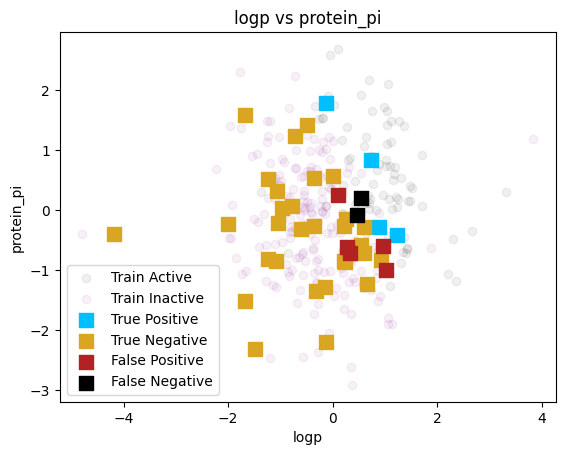

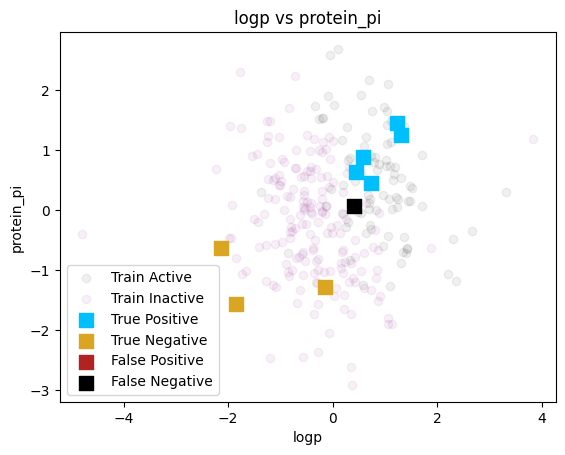

In [103]:
scatter_plot(results_rot_12)
scatter_plot(results_pid_170)